# Emulation of Waves
## Weather Typing + Probabilistic - Copula Model
## Predictor- Load Weather Types

In [1]:
from bluemath_tk.core.io import load_model

daily_xwt = load_model("/workspaces/BlueMath_Course_Corvallis/climate_services/probabilistic/MUSCLE/outputs/dwt_model.pkl")
dwts_to_fit = (
    daily_xwt.steps.get("pca")
    .pcs.kma_bmus.to_dataset(name="bmus")
    .sel(time=slice("1979", "2018"))
)
dwts_to_fit["cenEOFs"] = (
    ("n_clusters", "n_features"),
    daily_xwt.steps.get("kma").centroids,
)
dwts_to_fit

<xarray.Dataset> Size: 178kB
Dimensions:  (time: 14610, n_clusters: 36, n_features: 20)
Coordinates:
  * time     (time) datetime64[ns] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Dimensions without coordinates: n_clusters, n_features
Data variables:
    bmus     (time) int32 58kB 20 6 6 6 14 14 6 6 2 ... 29 29 21 35 35 35 35 21
    cenEOFs  (n_clusters, n_features) float32 3kB 10.55 3.774 ... -0.5882 -4.264

## Predictand- Load regional/local wave data
### significant wave height, peak period, mean wave direction

In [5]:
import pandas as pd

# # Option: download the daily buoy 46050 wave parameters from the GeoOcean THREDDS server
# # into toolkit/data (skipped if it already exists).
# buoy_url = "https://geoocean.unican.es/thredds/fileServer/rawData/GEOOCEAN/BlueMath_Course_Corvallis/buoy_46050_bulk_wave_parameters_daily.csv"
# !wget -nc -q --show-progress --no-check-certificate -P "/workspaces/BlueMath_Course_Corvallis/toolkit/data" "{buoy_url}"

predictand = (
    pd.read_csv(
        "/workspaces/BlueMath_Course_Corvallis/toolkit/data/buoy_46050_bulk_wave_parameters_daily.csv",
        parse_dates=["time"],
        index_col="time",
    )
    .to_xarray()
    .reindex(time=dwts_to_fit.time, method="nearest", tolerance="1h")
    .rename({"WVHT": "bulk_Hs", "DPD": "bulk_Tp", "MWD": "bulk_Dir"})  # APD = mean period
)
predictand["EF"] = predictand.bulk_Hs**2 + predictand.bulk_Tp
predictand["bmus"] = (("time"), dwts_to_fit["bmus"].values)

# The buoy has gaps and does not cover 1979-1991: drop days without data
predictand = predictand.dropna("time", subset=["bulk_Hs", "bulk_Tp", "bulk_Dir"])
predictand


<xarray.Dataset> Size: 268kB
Dimensions:   (time: 5152)
Coordinates:
  * time      (time) datetime64[ns] 41kB 1991-11-16 1991-11-17 ... 2018-12-31
Data variables:
    bulk_Hs   (time) float64 41kB 6.76 6.67 4.91 5.322 ... 2.559 3.118 2.629
    bulk_Tp   (time) float64 41kB 10.54 13.4 14.36 14.77 ... 15.62 12.02 10.66
    APD       (time) float64 41kB 8.54 9.685 9.657 9.078 ... 7.386 7.16 7.354
    bulk_Dir  (time) float64 41kB 201.6 259.1 270.2 275.4 ... 286.7 285.7 298.4
    EF        (time) float64 41kB 56.24 57.89 38.46 43.09 ... 22.17 21.74 17.57
    bmus      (time) int32 21kB 4 4 12 11 11 22 9 11 ... 29 29 21 35 35 35 35 21

In [6]:
import numpy as np

# Keep DWTs only on days with data
dwts_to_fit = dwts_to_fit.sel(time=predictand.time)


## Predictand to Predictor- Model
## Probabilistic - Copula Model

In [7]:
from bluemath_tk.teslakit.climate_emulator import Climate_Emulator

ce = Climate_Emulator("outputs/emulator")

config = {
    "waves_families": ["bulk"],
    "distribution": [],
    "do_chromosomes": False,
    "extra_variables": [],
}
ce.FitExtremes(KMA=dwts_to_fit, WVS=predictand, config=config, proxy="EF")

Waves Families: ['bulk']
Extra Variables: []
GEV distribution: ['bulk_Hs', 'bulk_Tp']
Empirical distribution: ['bulk_Dir']
Weibull distribution: []
Do chromosomes combinations: False
Max. Storms PROXY: EF


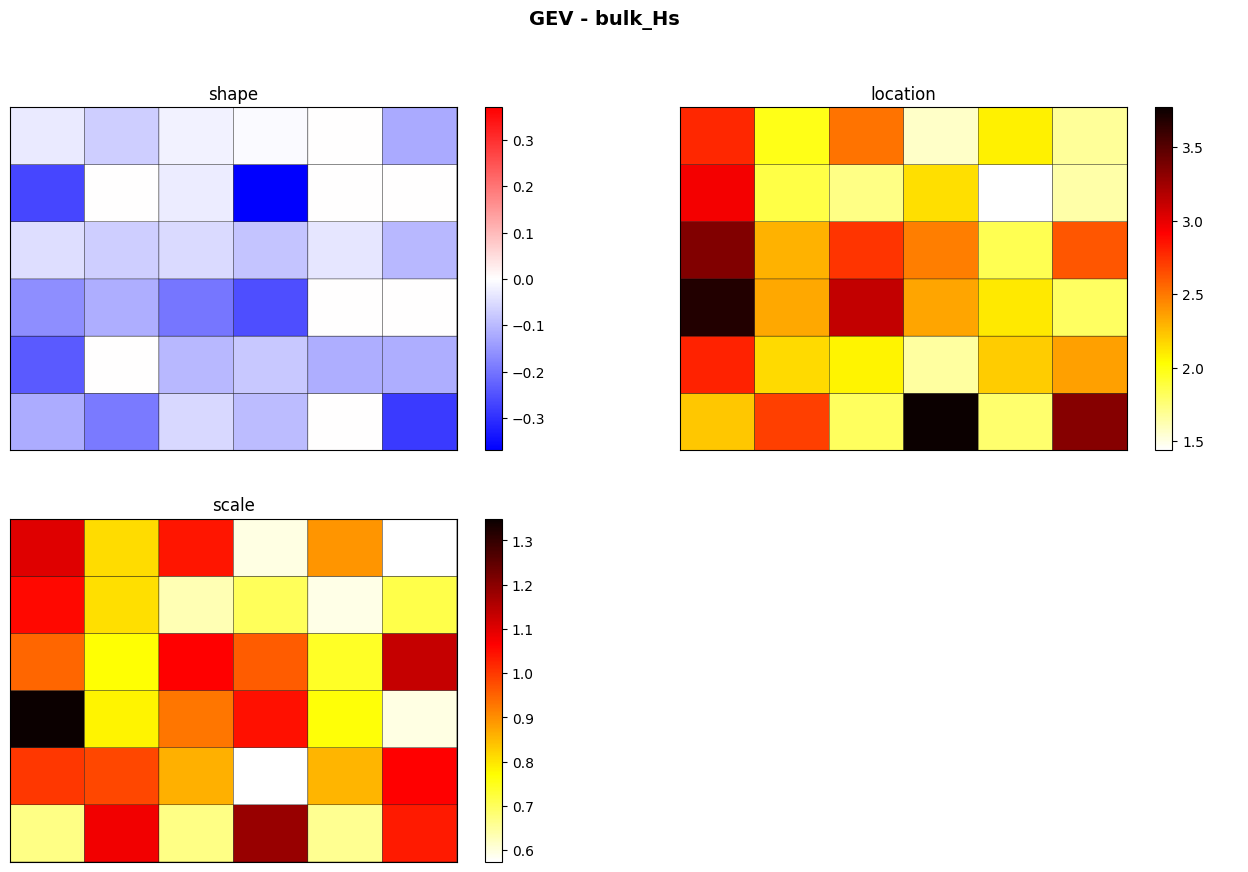

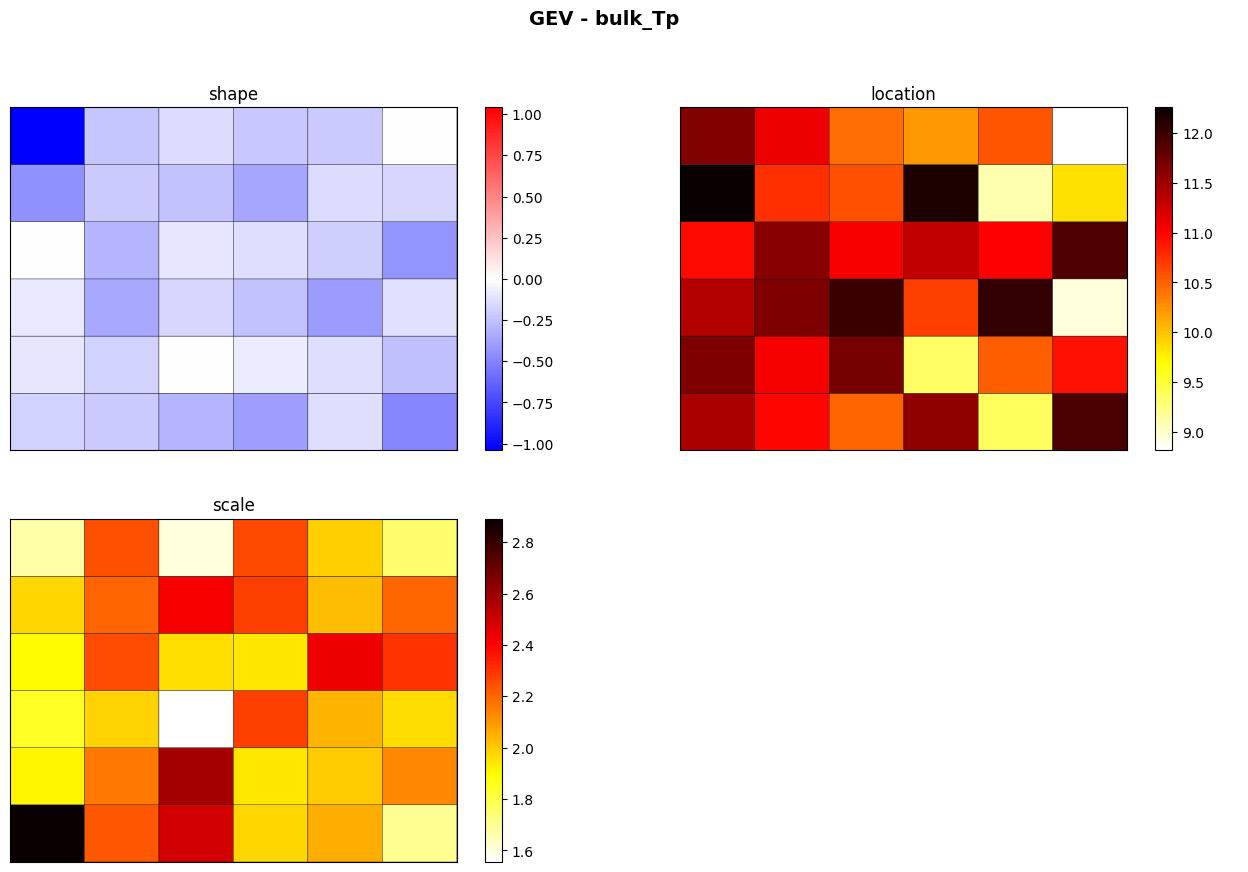

In [8]:
# Fit report figures

ce.Report_Fit(vns_GEV=["Hs", "Tp"], plot_chrom=False, plot_sigma=False);

## Climate Emulator
### Emulation of Weather Types + Emulation of Waves

In [9]:
# Load simulated DWTs
import xarray as xr

simulated_dwts = xr.open_dataset("/workspaces/BlueMath_Course_Corvallis/climate_services/probabilistic/MUSCLE/outputs/xds_output.nc")
simulated_dwts

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 36891, n_sim: 5)
Coordinates:
  * time         (time) datetime64[ns] 295kB 1999-01-01 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    evbmus_sims  (time, n_sim) int64 1MB ...
    ofbmus_sims  (time, n_sim) bool 184kB ...

In [10]:
simulated_waves = ce.Simulate_Waves(simulated_dwts.isel(n_sim=0), 1)
simulated_waves

C.E: Sim. Waves: 100%|██████████| 20647/20647 [00:48<00:00, 428.06it/s]


<xarray.Dataset> Size: 826kB
Dimensions:   (n_sim: 1, time: 20647)
Coordinates:
  * time      (time) datetime64[ns] 165kB 1999-01-01 1999-01-02 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    DWT       (n_sim, time) int64 165kB 6 4 9 7 15 2 1 2 4 ... 1 2 1 2 1 13 4 7
    bulk_Hs   (n_sim, time) float64 165kB 2.248 3.089 2.172 ... 4.393 3.782
    bulk_Tp   (n_sim, time) float64 165kB 18.92 15.12 9.051 ... 11.3 11.85 10.06
    bulk_Dir  (n_sim, time) float64 165kB 311.0 291.4 293.8 ... 280.4 227.0

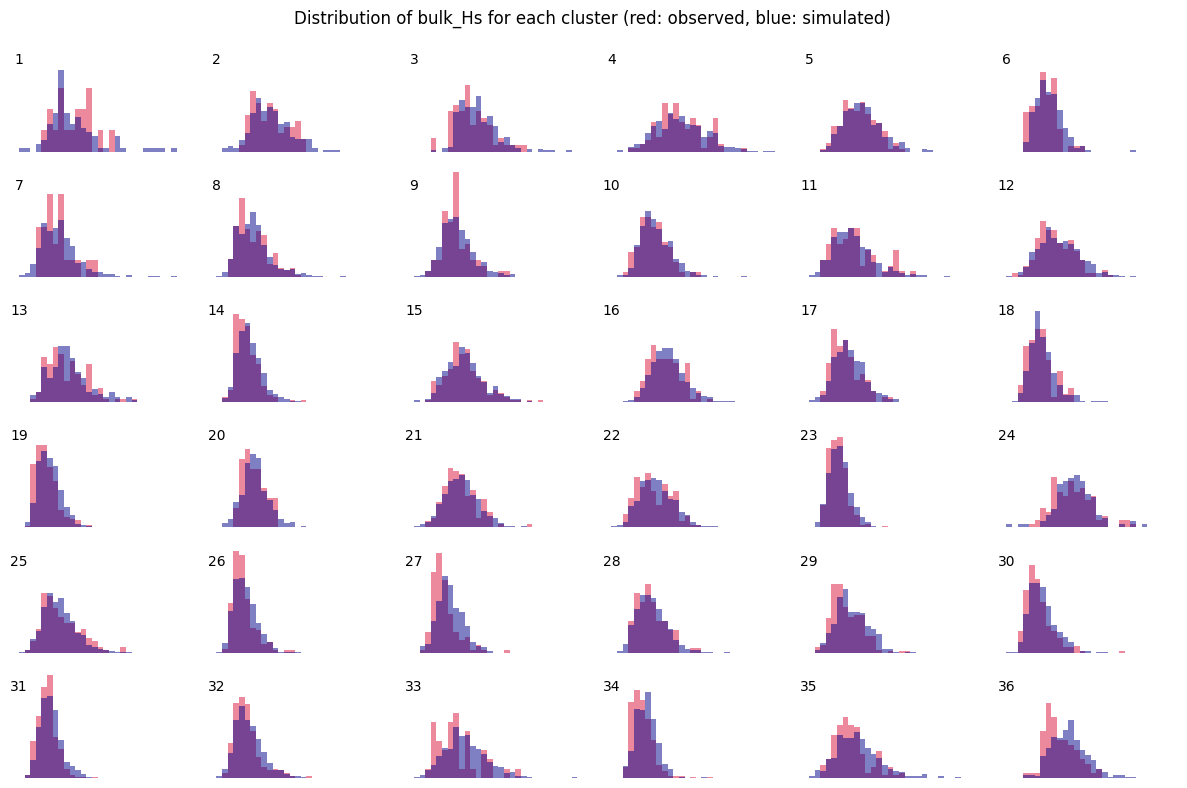

In [11]:
import matplotlib.pyplot as plt

var_to_plot = "bulk_Hs"

fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(time=predictand.groupby("bmus").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=np.linspace(0, 10, 30), color="crimson")
    simulated_waves.isel(time=simulated_waves.groupby("DWT").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=np.linspace(0, 10, 30), color="darkblue")
    ax.axis("off")
    ax.text(0, 0.7, f"{cluster + 1}", fontsize=10, ha="center", va="center")
    fig.suptitle(
        f"Distribution of {var_to_plot} for each cluster (red: observed, blue: simulated)",
        fontsize=12,
        ha="center",
        va="top",
    )
plt.subplots_adjust(top=0.9)
plt.tight_layout()

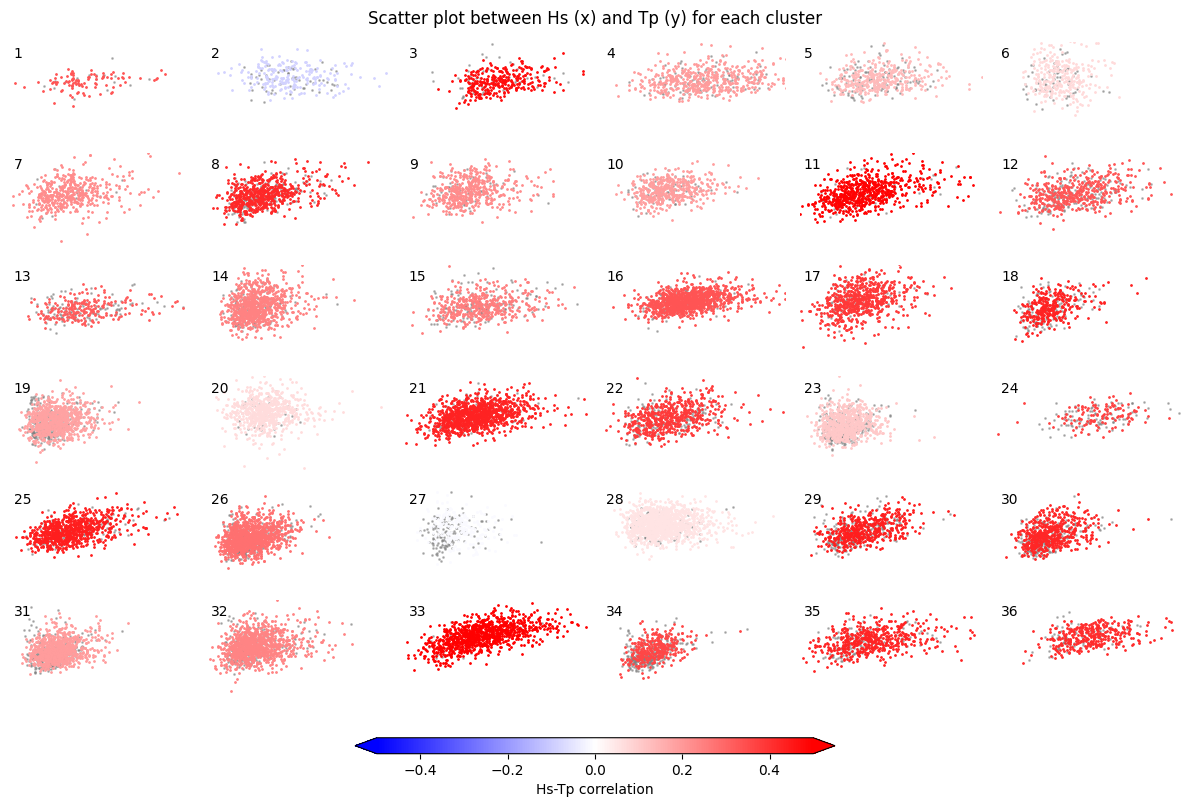

In [12]:
import matplotlib.colors as mcolors
import numpy as np

cmap = plt.cm.get_cmap("bwr")
norm = mcolors.Normalize(vmin=-0.5, vmax=0.5)
# Get correlation values
corr_values = np.array([ce.sigma[cluster][0]["corr"][0, 1] for cluster in range(1, 37)])
# Get colors for the correlation values
corr_values_colors = [cmap(norm(value)) for value in corr_values]
# Fixed limits from the observations: with sharex/sharey, a single extreme
# simulated value in one cluster squashed every panel
hs_lim = (0, 1.05 * float(predictand.bulk_Hs.quantile(0.999)))
tp_lim = (0, 1.05 * float(predictand.bulk_Tp.quantile(0.999)))
# Plot the correlation values
fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(
        time=predictand.groupby("bmus").groups.get(cluster + 1)
    ).plot.scatter(ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color="grey", alpha=0.5)
    simulated_waves.isel(
        time=simulated_waves.groupby("DWT").groups.get(cluster + 1)
    ).plot.scatter(
        ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color=corr_values_colors[cluster]
    )
    ax.axis("off")
    ax.text(0.02, 0.95, f"{cluster + 1}", fontsize=10, ha="left", va="top", transform=ax.transAxes)
axes[0, 0].set_xlim(hs_lim)
axes[0, 0].set_ylim(tp_lim)
fig.suptitle(
    "Scatter plot between Hs (x) and Tp (y) for each cluster",
    fontsize=12,
    ha="center",
    va="top",
)
plt.tight_layout()
# Colorbar: Hs-Tp correlation of the copula fitted for each DWT
fig.subplots_adjust(bottom=0.12)
cax = fig.add_axes([0.3, 0.05, 0.4, 0.02])
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax,
    orientation="horizontal",
    extend="both",
    label="Hs-Tp correlation",
)

## Extremes
### Annual maxima: historical vs simulations

In [13]:
# One wave simulation for each DWT simulation
n_sims = simulated_dwts.sizes["n_sim"]
waves_sims = [
    ce.Simulate_Waves(simulated_dwts.isel(n_sim=i), 1).isel(n_sim=0)
    for i in range(n_sims)
]

C.E: Sim. Waves: 100%|██████████| 20566/20566 [00:46<00:00, 446.16it/s]


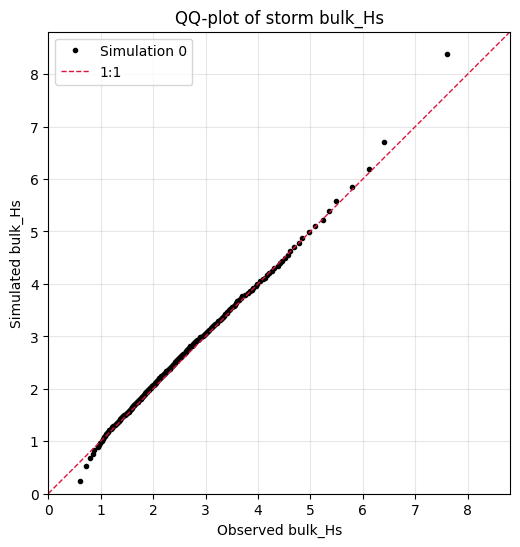

In [14]:
# QQ-plot of one simulation: quantiles of observed (fitted) vs simulated storms

var_ext = "bulk_Hs"

probs = np.linspace(0.001, 0.999, 200)
q_obs = np.nanquantile(ce.WVS_MS[var_ext], probs)
q_sim_0 = np.nanquantile(waves_sims[0][var_ext], probs)

lims = [0, 1.05 * max(q_obs.max(), q_sim_0.max())]
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(q_obs, q_sim_0, "o", ms=3, color="k", label="Simulation 0")
ax.plot(lims, lims, "--", color="crimson", lw=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel(f"Observed {var_ext}")
ax.set_ylabel(f"Simulated {var_ext}")
ax.set_title(f"QQ-plot of storm {var_ext}")
ax.grid(alpha=0.3)
ax.legend();

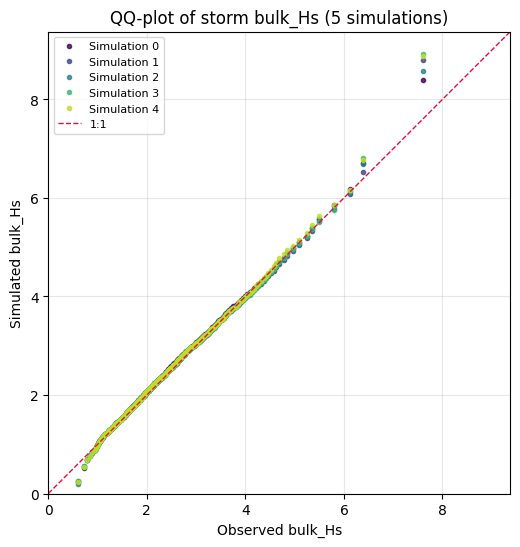

In [15]:
# QQ-plot of several simulations, one color each
n_sim = 5  # number of simulations to plot (max. n_sims)

n_sim = min(n_sim, n_sims)
colors = plt.cm.viridis(np.linspace(0, 0.9, n_sim))
q_sims = [np.nanquantile(waves_sims[i][var_ext], probs) for i in range(n_sim)]

lims = [0, 1.05 * max(q_obs.max(), max(q.max() for q in q_sims))]
fig, ax = plt.subplots(figsize=(6, 6))
for i, (q_sim, color) in enumerate(zip(q_sims, colors)):
    ax.plot(q_obs, q_sim, "o", ms=3, color=color, alpha=0.8, label=f"Simulation {i}")
ax.plot(lims, lims, "--", color="crimson", lw=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel(f"Observed {var_ext}")
ax.set_ylabel(f"Simulated {var_ext}")
ax.set_title(f"QQ-plot of storm {var_ext} ({n_sim} simulations)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8);